# Model Iteration Notebook 

In this notebook, we will focus on training and evaluating multiple machine learning models to classify emotions in transcribed television show data. 

The different secitons in this notebook will help demonstrate how different models perform on the same dataset and will provide insights into model selection and optimization. 

For every type of model and/or iteration that we did, we tracked the details in the model iteration file that you can find attached to the final assignment on Brightspace or here [Model Iteration File](link-here). In order to improve our models, we used (a selection of) traditional NLP features that we extracted in the ‘NLP Features’ task [NLP Features.ipynb notebook](NLP Features.ipynb). 



In [1]:
# Configure logging to suppress INFO messages from different libraries
import logging
logging.basicConfig()
logger = logging.getLogger()
logger.setLevel(logging.WARNING)

In [2]:
import sys
import os

# Get the directory of the current notebook (which is /notebooks/)
# and navigate up one level (to /project_root/) to find /src
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add the project root to the system path
if project_root not in sys.path:
    sys.path.append(project_root)

In [3]:
import numpy as np
import pandas as pd
from typing import Dict

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Set Keras Backend to use PyTorch
os.environ["KERAS_BACKEND"] = "torch"
import keras
import torch

print("Torch version:",torch.__version__)

print("Is CUDA enabled?",torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Torch version: 2.9.0+cu126
Is CUDA enabled? True


In [5]:
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    AutoConfig, 
    EarlyStoppingCallback
)
import evaluate

c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



In [6]:
# Emotion Map obtained from https://aclanthology.org/I17-1099/ --> readme.txt
EMOTION_MAP: Dict[int, str] = {
    0: "neutral", 1: "anger", 2: "disgust", 3: "fear",
    4: "happiness", 5: "sadness", 6: "surprise"
}

In [7]:
EMOTION_REVERSE_MAP = {v: k for k, v in EMOTION_MAP.items()}

In [8]:
df_concat = pd.read_csv(r"..\Data\CSV\sentiment_data\final_dataset.csv", nrows=388192)

In [9]:
# df_concat = pd.read_csv(r"..\Data\CSV\combined_emotion_dataset_filip.csv")

## Transformer Models 

In [10]:
transformers_data = df_concat.copy()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    transformers_data['Sentence'],
    transformers_data['Emotion_ID'],
    test_size=0.3,
    random_state=42,
    stratify=transformers_data['Emotion_ID'],
    shuffle=True
)

In [12]:
predictions = {}

In [13]:
# Data Preparation & Tokenization
def tokenize_data(checkpoint, X_train, y_train, X_test, y_test):
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)

    def tokenize_function(example):
        return tokenizer(example["text"], truncation=True, padding="max_length", max_length=128)

    train_df = pd.DataFrame({"text": X_train, "label": y_train})
    test_df = pd.DataFrame({"text": X_test, "label": y_test})

    train_dataset = Dataset.from_pandas(train_df)
    test_dataset = Dataset.from_pandas(test_df)

    tokenized_train = train_dataset.map(tokenize_function, batched=True)
    tokenized_test = test_dataset.map(tokenize_function, batched=True)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    return tokenizer, tokenized_train, tokenized_test, data_collator

In [14]:
def create_model_and_config(checkpoint, num_labels=7, freeze_model=False, 
                            unfreeze_classifier=False, num_unfrozen_encoder_layers=0, dropout_rate=0.1):
    
    config = AutoConfig.from_pretrained(checkpoint, num_labels=num_labels)

    config.hidden_dropout_prob = dropout_rate
    config.attention_probs_dropout_prob = dropout_rate
    print(f"Set hidden_dropout_prob and attention_probs_dropout_prob to: {dropout_rate}")

    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        config=config,
        ignore_mismatched_sizes=True
    )

    def identify_model(model):
        # Access the encoder layers based on known HUGGINGFACE conventions
        # This part requires some model-specific logic or a more general approach
        # For simplicity and coverage of common models (RoBERTa, BERT, DistilBERT):
        if hasattr(model, 'roberta'): # For RoBERTa-like models
            encoder_layers = model.roberta.encoder.layer
        elif hasattr(model, 'distilbert'): # For DistilBERT-like models
            encoder_layers = model.distilbert.transformer.layer
        elif hasattr(model, 'bert'): # For BERT-like models
             encoder_layers = model.bert.encoder.layer
        else:
             print("Warning: Could not identify encoder structure for unfreezing.")
             encoder_layers = []
        return encoder_layers
    
    # 1. Option to Freeze ALL parameters (except the classification head by default)
    if freeze_model:
        print("Freezing all parameters in the model body...")
        for name, param in model.named_parameters():
            param.requires_grad = False
    
    # 2. Unfreeze the final classification head
    if unfreeze_classifier:
        print("Unfreezing the final classification head (model.classifier/model.logits)...")
        # Most models (like RoBERTa and DistilBERT) use 'classifier' or 'pre_classifier'/'classifier'
        # or have the final layer accessible. We iterate over all named parameters 
        # to ensure it works across different architectures.
        for name, param in model.named_parameters():
            if 'classifier' in name or 'logits' in name:
                 param.requires_grad = True

    # 3. Unfreeze the LAST N encoder layers
    if num_unfrozen_encoder_layers > 0:
        print(f"Unfreezing the LAST {num_unfrozen_encoder_layers} encoder layers...")
        
        encoder_layers = identify_model(model)

        total_layers = len(encoder_layers)
        start_index = max(0, total_layers - num_unfrozen_encoder_layers)

        for i in range(start_index, total_layers):
            layer = encoder_layers[i]
            for param in layer.parameters():
                param.requires_grad = True
    elif num_unfrozen_encoder_layers == 0:
        pass
    else:
        print(f"Unfreezing all encoder layers...")

        encoder_layers = identify_model(model)

        total_layers = len(encoder_layers)
        start_index = 0

        for i in range(start_index, total_layers):
            layer = encoder_layers[i]
            for param in layer.parameters():
                param.requires_grad = True

    return model

def create_training_args():
    return TrainingArguments(
        output_dir="./transformer-outputs",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=1e-5,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        num_train_epochs=3,
        fp16=True,
        weight_decay=0.05,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        logging_dir="./logs",
        logging_steps=50
    )

In [15]:
# Evaluation Metrics
def compute_metrics(eval_pred):
    accuracy_metric = evaluate.load("accuracy")
    f1_metric = evaluate.load("f1")

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")

    return {"accuracy": acc["accuracy"], "f1_weighted": f1["f1"]}

In [16]:
# Trainer Setup
def setup_trainer(model, tokenizer, training_args, train_set, test_set, data_collator):
    return Trainer(
        model=model,
        args=training_args,
        train_dataset=train_set,
        eval_dataset=test_set,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

In [17]:
def load_or_train_model(base_checkpoint, fallback_checkpoint,
                        X_train, y_train, X_test, y_test, show_params=False,
                        unfreeze_classifier=False, num_unfrozen_encoder_layers=0, dropout_rate=0.1): # <--- New Parameters
    
    model_exists = os.path.exists(base_checkpoint)

    try:
        print(f"Loading tokenizer and model from {base_checkpoint}...")
        # Tokenizer is always loaded from the checkpoint or fallback
        tokenizer, train_ds, test_ds, collator = tokenize_data(base_checkpoint, X_train, y_train, X_test, y_test)
        
        # 1. Load trained model directly if it exists
        model = AutoModelForSequenceClassification.from_pretrained(base_checkpoint)
        
    except OSError:
        print(f"Failed to load {base_checkpoint}, falling back to {fallback_checkpoint}...")
        tokenizer, train_ds, test_ds, collator = tokenize_data(fallback_checkpoint, X_train, y_train, X_test, y_test)
        
        # 2. Create and configure a NEW model from the fallback checkpoint
        # This is where the unfreezing logic is applied for NEW models
        model = create_model_and_config(
            fallback_checkpoint, 
            num_labels=7, # Assuming 7 labels from config function
            freeze_model=True, # Often set to True when unfreezing specific layers
            unfreeze_classifier=unfreeze_classifier, # <--- Pass the new flags
            num_unfrozen_encoder_layers=num_unfrozen_encoder_layers,
            dropout_rate=dropout_rate
        )
        model_exists = False # Model is being created, so set this for training

    if show_params:
        # This will now reflect the parameters set by the unfreezing logic
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"✅ Total Trainable Parameters: {trainable_params }")

    training_args = create_training_args()
    trainer = setup_trainer(model, tokenizer, training_args, train_ds, test_ds, collator)

    if model_exists:
        print("The model was loaded successfully (no training needed).")
    else:
        # Train new model
        print("Training new model...")
        trainer.train()

        # Save the model and tokenizer
        print(f"Saving trained model to {base_checkpoint}...")
        trainer.save_model(base_checkpoint)

    return model, tokenizer, trainer, train_ds, test_ds

In [18]:
# checkpoint = "transformer-models/test-model"
# fallback = "distilbert-base-uncased-finetuned-sst-2-english"

# model, tokenizer, trainer, train_ds, test_ds = load_or_train_model(
#     base_checkpoint=checkpoint,
#     fallback_checkpoint=fallback,
#     X_train=X_train,
#     y_train=y_train,
#     X_test=X_test,
#     y_test=y_test,
#     show_params=True,
#     unfreeze_classifier=True,
#     num_unfrozen_encoder_layers=0
# )

In [19]:
# df_concat = pd.read_csv(r"..\Data\CSV\sentiment_data\exp_dataset.csv")
df_concat = pd.read_csv(r"..\Data\CSV\combined_emotion_dataset_filip.csv")

In [20]:
# Balance dataset (you can adjust n=5000)
transformers_data = []
unique_emotions = df_concat['Emotion'].unique()

for emotion in unique_emotions:
    emotion_rows = df_concat[df_concat['Emotion'] == emotion]
    sampled_rows = emotion_rows.sample(n=10000, replace=True, random_state=42)
    transformers_data.append(sampled_rows)

transformers_data = pd.concat(transformers_data, ignore_index=True)
transformers_data['Emotion_ID'] = transformers_data['Emotion_ID'].astype(int)
transformers_data = transformers_data.drop(columns=['Unnamed: 0', 'Emotion'], errors='ignore')

In [21]:
# df_concat = pd.read_csv(r"filip_filip_filip.csv")
# columns_to_keep = ["Sentence", "Emotion_ID"]
# transformers_data = df_concat[columns_to_keep].copy()

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    transformers_data['Sentence'],
    transformers_data['Emotion_ID'],
    test_size=0.1,
    random_state=42,
    stratify=transformers_data['Emotion_ID'],
    shuffle=True
)

In [23]:
def create_training_args():
    return TrainingArguments(
        output_dir="./transformer-outputs",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=3e-5,
        per_device_train_batch_size=64,
        per_device_eval_batch_size=64,
        num_train_epochs=100,
        fp16=True,
        weight_decay=0.02,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        logging_dir="./logs",
        logging_steps=50
    )

In [24]:
checkpoint = "transformer-models/test-model-fine"
# fallback = "transformer-models/test-model"
fallback = "siebert/sentiment-roberta-large-english"

model, tokenizer, trainer, train_ds, test_ds = load_or_train_model(
    base_checkpoint=checkpoint,
    fallback_checkpoint=fallback,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    show_params=True,
    unfreeze_classifier=True,
    num_unfrozen_encoder_layers=-1,
    dropout_rate=0.4
)

Loading tokenizer and model from transformer-models/test-model-fine...
Failed to load transformer-models/test-model-fine, falling back to siebert/sentiment-roberta-large-english...


Map: 100%|██████████| 7000/7000 [00:00<00:00, 24858.57 examples/s]


Set hidden_dropout_prob and attention_probs_dropout_prob to: 0.4


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at siebert/sentiment-roberta-large-english and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 1024]) in the checkpoint and torch.Size([7, 1024]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([7]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Freezing all parameters in the model body...
Unfreezing the final classification head (model.classifier/model.logits)...
Unfreezing all encoder layers...
✅ Total Trainable Parameters: 303366151
Training new model...


KeyboardInterrupt: 

In [ ]:
preds = trainer.predict(test_ds)
y_pred = np.argmax(preds.predictions, axis=-1)
y_true = np.array(test_ds["label"])

predictions["DistilBERT-base-uncased"] = y_pred

print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.571     0.479     0.521       167
           1      0.000     0.000     0.000        28
           2      0.000     0.000     0.000        11
           3      0.000     0.000     0.000        31
           4      0.493     0.773     0.602        88
           5      0.223     0.558     0.319        52
           6      0.000     0.000     0.000        31

    accuracy                          0.434       408
   macro avg      0.184     0.258     0.206       408
weighted avg      0.369     0.434     0.384       408



c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

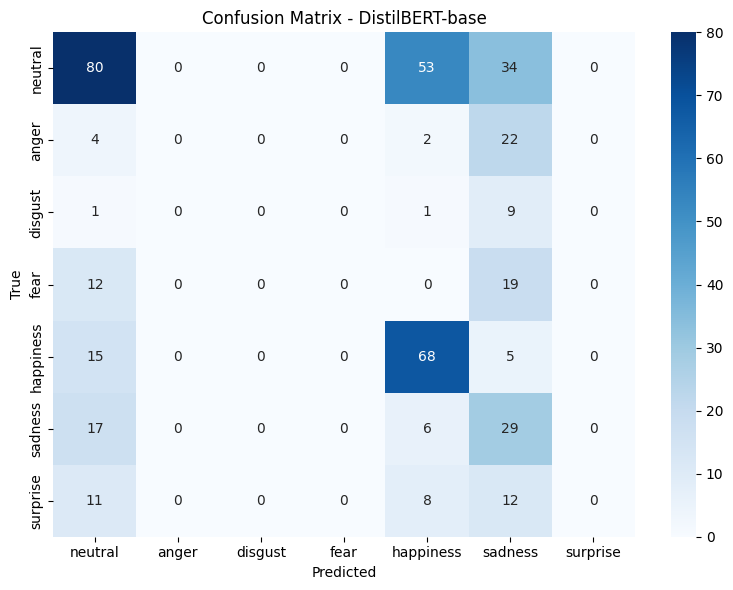

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - DistilBERT-base')
plt.tight_layout()
plt.show()

## Testing the best models 

In [25]:
from src.predict import EmotionCorePredictor

In [26]:
df_test = pd.read_excel(r'../Data/CSV/final_transcript_with_annotated_labels.xlsx')
# df_test = pd.read_csv(r"..\Data\CSV\sentiment_data\exp_dataset.csv", nrows=100000)

In [27]:
df_test.head()

,Sentence,Emotion_core,LLM_Emotions,Filip_Emotion
0,"La Verne, California, just 30 miles from Los A...",neutral,neutral,neutral
1,this suburb is home to a neighborhood Italian ...,happiness,happiness,happiness
2,called Charlie's.,neutral,neutral,neutral
3,"And in 2010, it was bought by the Leyva family.",neutral,neutral,neutral
4,Would you like a booth?,neutral,neutral,neutral


In [30]:
columns_to_keep = ["Sentence", "Filip_Emotion"]

transformers_data = df_test[columns_to_keep].copy()

# Now safely map the labels
transformers_data["Filip_Emotion"] = transformers_data["Filip_Emotion"].map(EMOTION_REVERSE_MAP)

In [31]:
X, y = transformers_data['Sentence'], transformers_data['Filip_Emotion']

In [39]:
models = []

roberta_finer ="transformer-models/roberta-finer"
models.append(roberta_finer)
# roberta_fine ="transformer-models/roberta-fine"
# models.append(roberta_fine)
# roberta_large ="transformer-models/roberta-large"
# models.append(roberta_large)
# distilbert = "transformer-models/distilbert-fine"
# models.append(distilbert)
# model_fine = "transformer-models/test-model-fine"
# models.append(model_fine)

In [40]:
predictions = {}

for model in models:
    # 1. Split the string by '/'
    parts = model.split('/')
    
    # 2. Get the last part, which is the model name (e.g., 'distilbert-base')
    model_name = parts[-1] 
    
    # Initialize and Run PredictEngine
    engine = EmotionCorePredictor(
        checkpoint=model
    )
    
    # Use the extracted model_name as the key in the predictions dictionary
    predictions[model_name] = engine.predict(df=transformers_data, column='Sentence')

Map: 100%|██████████| 1227/1227 [00:00<00:00, 25038.61 examples/s]


In [41]:
from collections import Counter

# Convert predictions dict to DataFrame
pred_df = pd.DataFrame(predictions)

# Apply majority voting row-wise
def majority_vote(row):
    vote_counts = Counter(row)
    return vote_counts.most_common(1)[0][0]

final_predictions = pred_df.apply(majority_vote, axis=1)
y_true = np.array(y)

In [42]:
# 1. Calculate F1 Score
f1 = f1_score(y_true, final_predictions, average='weighted')

# 2. Calculate Accuracy Score
accuracy = accuracy_score(y_true, final_predictions)

print(f"The F1 score is {f1:.3f}")
print(f"The accuracy is {accuracy:.3f}")
print(classification_report(y_true, final_predictions))

The F1 score is 0.682
The accuracy is 0.694
              precision    recall  f1-score   support

           0       0.75      0.84      0.79       591
           1       0.67      0.47      0.55       178
           2       0.74      0.25      0.37        57
           3       0.45      0.34      0.39        44
           4       0.69      0.80      0.74       167
           5       0.48      0.57      0.52        99
           6       0.67      0.59      0.63        91

    accuracy                           0.69      1227
   macro avg       0.64      0.55      0.57      1227
weighted avg       0.69      0.69      0.68      1227



In [43]:
y_true = np.array(y)

for model_name, y_pred in predictions.items():
    print(f'--- Results for {model_name} ---')
    
    # 1. Calculate F1 Score
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    # 2. Calculate Accuracy Score
    accuracy = accuracy_score(y_true, y_pred)
    
    print(f"The F1 score for the {model_name} model is {f1:.3f}")
    print(f"The accuracy for the {model_name} model is {accuracy:.3f}")
    print(classification_report(y_true, y_pred))

--- Results for roberta-finer ---
The F1 score for the roberta-finer model is 0.682
The accuracy for the roberta-finer model is 0.694
              precision    recall  f1-score   support

           0       0.75      0.84      0.79       591
           1       0.67      0.47      0.55       178
           2       0.74      0.25      0.37        57
           3       0.45      0.34      0.39        44
           4       0.69      0.80      0.74       167
           5       0.48      0.57      0.52        99
           6       0.67      0.59      0.63        91

    accuracy                           0.69      1227
   macro avg       0.64      0.55      0.57      1227
weighted avg       0.69      0.69      0.68      1227

